plot_optimization_search notebook
- Generates visualization of search algorithm evaluations and objectives,  namely convex hull volume plots, and pairwise pareto plots (for NGSA-II). 
    - These are indicators of search diversity and tradeoff structure across objectives
- Ensure the <u>Python 3.11 kernel (falcon-env)</u> is selected.
- Run configuration and functions before plotting
    - 3D convex hull plot requires at least 3 input params
- Note: This script requires optimized formulations generated from run_FALCON.py.

In [37]:
### Required Run Parameters ### 

RUN_NAME = "flexible_param_test" #Name of folder from which to load the model
opt_methods = ['NSGAII', 'BO','DA'] # DA, BO, NSGAII
cell_type = "THP1" #Cell type of model to load 

##### Configuration #####

In [38]:
import pandas as pd
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from sklearn.preprocessing import MinMaxScaler
import pickle
import os
import numpy as np

import sys
sys.path.append("..") 
from falcon_engine.run_optimization import run_optimization_pipeline


In [25]:
# load the evaluations 
def load_evaluations(run_name, opt_method):
    file_path = f"../output/{run_name}/{opt_method}_all_evaluations.csv"
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File {file_path} does not exist.")
    return pd.read_csv(file_path)

In [26]:
# convex hull plotting function 

def analyze_convex_hull_from_uploaded(df, save_path):
    # Ensure the column names match
    param_cols = [col for col in df.columns if 'LnRLU' not in col]

    params_raw = df[param_cols].values

    rlu_col = next((col for col in df.columns if col.lower().startswith('predicted_')), None)
    rlu_values = df[rlu_col].values  # for color coding

    # Explicit min-max normalization
    scaler = MinMaxScaler()
    params_scaled = scaler.fit_transform(params_raw)

    # Compute 4D convex hull
    hull = ConvexHull(params_scaled)
    hull_volume = hull.volume

    # Reduce to 3D for visualization
    params_3d = params_scaled[:, :3]
    hull_3d = ConvexHull(params_3d)

    # 3D plot
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Color scatter by RLU using a contrasting colormap
    scatter = ax.scatter(params_3d[:, 0], params_3d[:, 1], params_3d[:, 2],
                         c=rlu_values, cmap='RdYlBu', s=10, alpha = 0.7)

    # Draw filled convex hull with black outline
    for simplex in hull_3d.simplices:
        tri = Poly3DCollection([params_3d[simplex]], alpha=0.3,
                               facecolor='cyan', edgecolor='black', linewidths=1.0)
        ax.add_collection3d(tri)

    # Axis labels and formatting
    ax.set_xlabel(f'Scaled {param_cols[0]}', fontsize=12)
    ax.set_ylabel(f'Scaled {param_cols[1]}', fontsize=12)
    ax.set_zlabel(f'Scaled {param_cols[2]}', fontsize=12)
    ax.set_title('3D Convex Hull of LNP Compositions')

    #increase tick and axes label size
    ax.tick_params(axis='both', labelsize=12)
    ax.xaxis.labelpad = 8
    ax.yaxis.labelpad = 8
    ax.zaxis.labelpad = 8

    # Add color bar for RLU
    cbar = fig.colorbar(scatter, ax=ax, shrink=0.6, pad=0.1)
    cbar.set_label('Predicted LnRLU (Target Cell Type)')

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()

    # Print volume and count
    print(f"Convex Hull Volume in 4D (after normalization): {hull_volume:.4f}")
    print(f"Total number of evaluated points: {len(df)}")

In [51]:
# pairwise NSGAII plotting function 

def plot_pairwise_pareto(pareto_optimal, direction, all_F, cell_type_names=None, save_path=None):
    """
    Plots pairwise Pareto fronts and non-optimal evaluations.

    Parameters:
    - pareto_optimal: ndarray of shape (n_pareto, n_obj)
    - history: list of generations (as returned from NSGA-II res.history)
    - cell_type_names: list of names for each objective (optional)
    - save_path: path to save the figure (optional)
    """

    # Get all F values from historical population
    all_F = all_F.copy() 
    pareto_optimal = pareto_optimal.copy()

    pareto_optimal = pareto_optimal * np.array(direction)
    all_F = all_F * np.array(direction)

    # Filter non-optimal points
    tolerance = 1e-7
    mask = ~np.any(np.all(np.isclose(all_F[:, None], pareto_optimal[None, :], atol=tolerance), axis=2), axis=1)
    non_optimal = all_F[mask]

    # Subsample for efficiency
    max_non_opt = 10000
    if len(non_optimal) > max_non_opt:
        idx = np.random.choice(len(non_optimal), size=max_non_opt, replace=False)
        non_optimal = non_optimal[idx]

    # Objective count
    n_obj = pareto_optimal.shape[1]
    if not cell_type_names or len(cell_type_names) != n_obj:
        cell_type_names = [f"Objective {i+1}" for i in range(n_obj)]

    # Style setup
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.linewidth'] = 1
    plt.rcParams['xtick.major.width'] = 1
    plt.rcParams['ytick.major.width'] = 1
    plt.rcParams['xtick.major.size'] = 10
    plt.rcParams['ytick.major.size'] = 10

    fig, axes = plt.subplots(n_obj, n_obj, figsize=(2.5 * n_obj, 2.5 * n_obj))
    plt.subplots_adjust(hspace=0.25, wspace=0.25)

    for i in range(n_obj):
        for j in range(n_obj):
            ax = axes[i, j]

            if j >= i:
                ax.set_visible(False)
                continue

            ax.scatter(non_optimal[:, j], non_optimal[:, i], color="grey", s=40, alpha=0.2, zorder=1)
            ax.scatter(pareto_optimal[:, j], pareto_optimal[:, i],
                       facecolor="#EECCF9", edgecolor="black", linewidths=1, s=100, zorder=2)

            if j == 0:
                ax.set_ylabel(cell_type_names[i], fontsize=14)
            else:
                ax.set_yticklabels([])
            if i == n_obj - 1:
                ax.set_xlabel(cell_type_names[j], fontsize=14)
            else:
                ax.set_xticklabels([])

            ax.tick_params(axis='both', labelsize=12)

    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()


In [27]:
# Define the output path
output_path = os.path.join("..", "output", RUN_NAME)

convex_save_path = os.path.join(output_path, "convex_hull")

if not os.path.exists(convex_save_path):
    print("Creating directory at:", convex_save_path)
    os.makedirs(convex_save_path)
else:
    print("Directory already exists at:", convex_save_path)


Creating directory at: ..\output\flexible_param_test\convex_hull


##### Convex Hull Plots #####

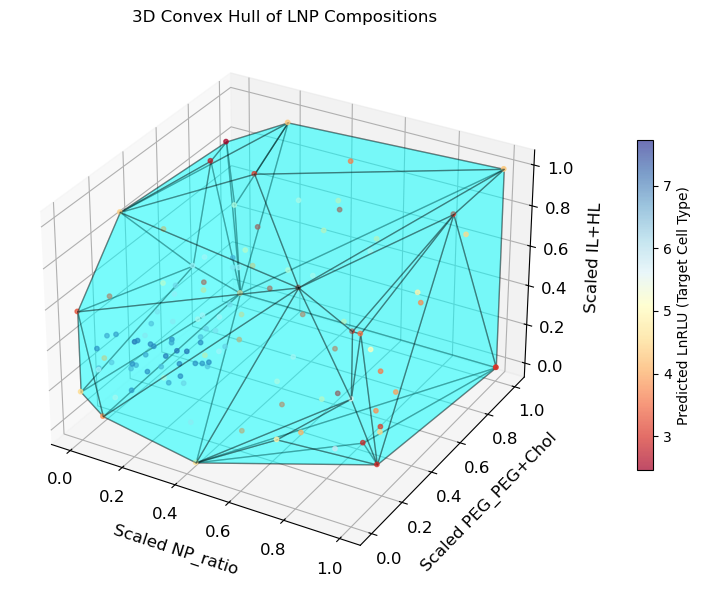

Convex Hull Volume in 4D (after normalization): 0.6545
Total number of evaluated points: 120


In [15]:
# BO convex hull analysis 
save_path = f"../output/{RUN_NAME}/convex_hull/BO_convex_hull.png"
BO_df= load_evaluations(RUN_NAME, 'BO')
analyze_convex_hull_from_uploaded(BO_df, save_path)

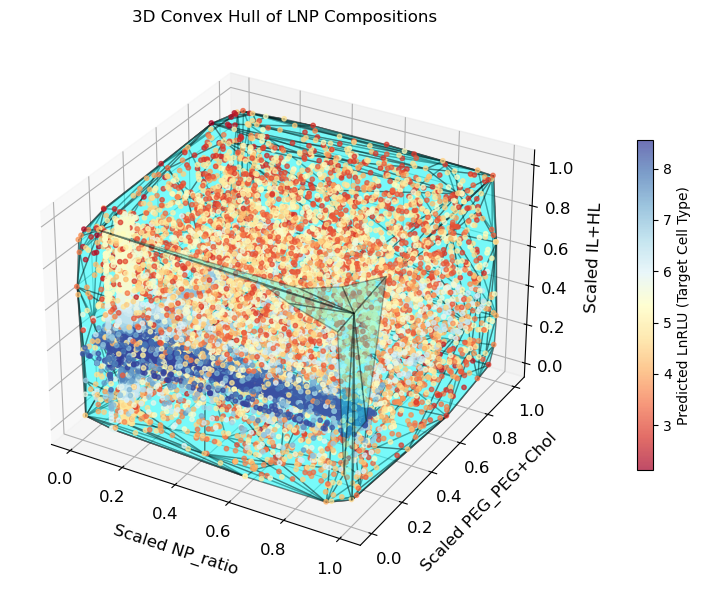

Convex Hull Volume in 4D (after normalization): 0.9561
Total number of evaluated points: 16179


In [16]:
# DA convex hull analysis 
save_path = f"../output/{RUN_NAME}/convex_hull/DA_convex_hull.png"
DA_df= load_evaluations(RUN_NAME, 'DA')
analyze_convex_hull_from_uploaded(DA_df, save_path)

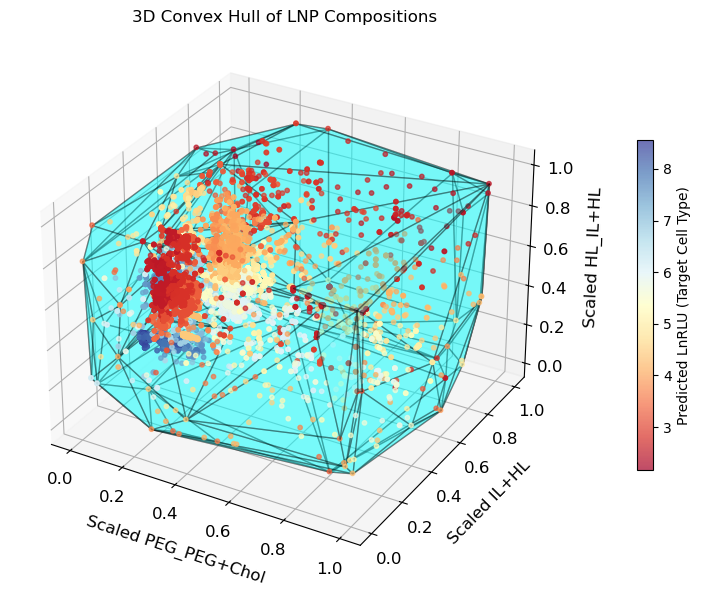

Convex Hull Volume in 4D (after normalization): 0.9156
Total number of evaluated points: 125000


In [28]:
# NSGAII convex hull analysis 
save_path = f"../output/{RUN_NAME}/convex_hull/NSGAII_convex_hull.png"
NSGAII_df= load_evaluations(RUN_NAME, 'NSGAII')
analyze_convex_hull_from_uploaded(NSGAII_df, save_path)

##### Pairwise pareto front plots (only for NSGA-II) #####

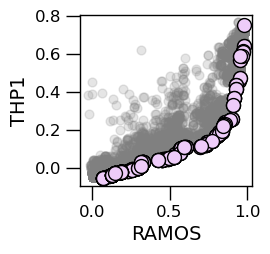

In [52]:
# load NSGAII results 
with open(f"../output/{RUN_NAME}/NSGAII_results.pkl", "rb") as f:
    data = pickle.load(f)

pareto_optimal = data['pareto_F']
all_F = data['all_F']
cell_type_names = data['cell_type_names']
direction = data['direction']

plot_pairwise_pareto(pareto_optimal, direction, all_F, cell_type_names, 
                     save_path=f"../output/{RUN_NAME}/pairwise_pareto_plot.png")